# PROJECT: 2
# EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING

**Problem statement:**

 Every company loses employees — but losing the wrong employees at the wrong time costs the business heavily in hiring, training, and lost productivity. HR departments at large companies spend crores every year trying to figure out who is likely to leave and why — before it happens. This is called Employee Attrition Prediction, and it is one of the most widely used real-world applications of data science in the corporate world today.

# Task 1. Data loading & Exploration

In [1]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load the csv
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition (1).csv')

In [5]:
# display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [50]:
# check how many rows and columns are present in the dataset
df.shape

(1470, 35)

In [51]:
# identifying the target column
# target column
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [49]:
# how many employees left vs stayed and calculate the attrition rate as a percentage
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / attrition_counts.sum()) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")
print("Employee counts:")
print(attrition_counts)
print()
print("Attrition rate (%):")
print(attrition_rate.round(2))
print()
print(f"==> {attrition_counts['Yes']} employees left out of {len(df)} "
      f"({attrition_rate:.2f}% attrition rate)")

Attrition Rate: 16.12%
Employee counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate (%):
16.12

==> 237 employees left out of 1470 (16.12% attrition rate)


In [11]:
# Identify how many columns are numeric vs categorical
numeric_columns = x.select_dtypes(include=np.number).columns
categorical_columns = x.select_dtypes(exclude=np.number).columns
print(f"Numeric Columns: {len(numeric_columns)}")
print(f"Categorical Columns: {len(categorical_columns)}")


Numeric Columns: 26
Categorical Columns: 8


**Write one observation:**

**Observation — Is attrition balanced or imbalanced?**

The attrition rate is **16.12%** (237 left vs 1,233 stayed) — this is a **clearly imbalanced**
target. Roughly 1 in 6 employees left, so a naive model that always predicts "No" would already
be ~84% "accurate" while being completely useless for HR. This means:
- **Accuracy is not a meaningful metric** here — we need Precision, Recall, F1, and ROC-AUC instead.
- We need to explicitly handle the imbalance during modeling (`class_weight='balanced'` or sample
  weights), otherwise models will be biased toward predicting "stays" and miss the leavers HR
  actually cares about.

One more nuance worth flagging: of the 26 "numeric" columns, several are actually **ordinal
rating scales stored as integers** (e.g. `JobSatisfaction`, `WorkLifeBalance`, `Education`,
`EnvironmentSatisfaction` — all 1–4 or 1–5 scales), not continuous measurements. We'll keep this
in mind during EDA and scaling.

# Task 2. Data cleaning & preprocessing


In [12]:
# Check for missing/null values and handle them
df.isnull().sum()
print(df.isnull().sum())


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

There are no null values in this dataset

In [13]:
# Drop columns that add no value to prediction
# EmployeeNumber -> just a unique ID, EmployeeCount/StandardHours/Over18 -> constant for every row
for col in ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']:
    print(f"{col}: {df[col].nunique()} unique value(s) -> {df[col].unique()[:3]}")

drop_cols = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=drop_cols)
print(f"\nDropped {drop_cols}")
print(f"Shape after dropping: {df_clean.shape}")

EmployeeCount: 1 unique value(s) -> [1]
Over18: 1 unique value(s) -> ['Y']
StandardHours: 1 unique value(s) -> [80]
EmployeeNumber: 1470 unique value(s) -> [1 2 4]

Dropped ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Shape after dropping: (1470, 31)


In [14]:
# Convert target Attrition: Yes/No -> 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [15]:
# Keep a clean, still-readable copy for EDA
df_eda = df_clean.copy()
df_eda.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


In [16]:
# One-Hot Encode all remaining categorical columns
categorical_cols_remaining = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {categorical_cols_remaining}")

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols_remaining, drop_first=True)
print(f"\nShape before encoding: {df_clean.shape}")
print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head(3)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape before encoding: (1470, 31)
Shape after one-hot encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True


In [18]:
# Scale numeric features using StandardScaler
# Demonstrated here on the full encoded dataframe to satisfy the preprocessing step.
# NOTE: we will NOT use this full-data-fitted scaler for the actual train/test modeling in
# Task 4 -- fitting the scaler on the full dataset (including what will become the test set)
# leaks test-set distribution information into training. In Task 4 we re-split first, then
# fit StandardScaler on X_train only and apply it to X_test, which is the methodologically
# correct approach.

from sklearn.preprocessing import StandardScaler
feature_cols = [c for c in df_encoded.columns if c != 'Attrition']
scaler_demo = StandardScaler()
df_model_full = df_encoded.copy()
df_model_full[feature_cols] = scaler_demo.fit_transform(df_model_full[feature_cols])

print("Scaled feature preview:")
df_model_full.head(3)

Scaled feature preview:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746


# Task 3. Exploratory Data Analysis — EDA

In [19]:
# Attrition rate by Department
dept_attr = (df_eda.groupby('Department')['Attrition'].mean() * 100).sort_values(ascending=False)
dept_count = df_eda['Department'].value_counts()

dept_summary = pd.DataFrame({'Attrition Rate (%)': dept_attr.round(2), 'Headcount': dept_count})
dept_summary = dept_summary.sort_values('Attrition Rate (%)', ascending=False)
dept_summary

,Attrition Rate (%),Headcount
Department,,
Sales,20.63,446
Human Resources,19.05,63
Research & Development,13.84,961


**which department loses the most employees?**

**Sales** has the highest departmental attrition rate (**20.63%**, 446 employees), followed by
**Human Resources** (**19.05%**, but a tiny department of only 63 people), and **Research &
Development** is the most stable (**13.84%**, the largest department at 961 employees).

In [20]:
# Attrition rate by Job Role
role_attr = (df_eda.groupby('JobRole')['Attrition'].mean() * 100).sort_values(ascending=False)
role_count = df_eda['JobRole'].value_counts()

role_summary = pd.DataFrame({'Attrition Rate (%)': role_attr.round(2), 'Headcount': role_count.reindex(role_attr.index)})
role_summary

,Attrition Rate (%),Headcount
JobRole,,
Sales Representative,39.76,83
Laboratory Technician,23.94,259
Human Resources,23.08,52
Sales Executive,17.48,326
Research Scientist,16.10,292
Manufacturing Director,6.90,145
Healthcare Representative,6.87,131
Manager,4.90,102
Research Director,2.50,80


**which roles have the highest exit rate?**

**Sales Representative** is by far the highest-risk role at **39.76%** attrition (83 employees) —
more than double the company-wide average of 16.12%. **Laboratory Technician** (23.94%, 259
employees) and **Human Resources** (23.08%, 52 employees) round out the top three. At the other
end, **Research Director** (2.5%) and **Manager** (4.9%) are the most stable roles — likely
reflecting seniority and pay.

In [21]:
# Attrition vs Monthly Income
income_summary = df_eda.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'std']).round(0)
income_summary.index = ['Stayed (0)', 'Left (1)']
income_summary


,mean,median,std
Stayed (0),6833.0,5204.0,4818.0
Left (1),4787.0,3202.0,3640.0


**do lower paid employees leave more?**

Employees who left earn noticeably less on average: a **mean of $4,787** vs **$6,833** for
those who stayed (median $3,202 vs $5,204) — roughly a **30% lower average income**. So yes,
there is a clear *univariate* pay gap. **But** — as we'll see in the model's feature importances
in Task 5 — once other factors (overtime, role, travel, tenure) are accounted for, raw
`MonthlyIncome` is **not** among the top drivers. Pay correlates with attrition mostly because it
correlates with job level/role/tenure, which are the more direct causes.

In [22]:
# Attrition vs Work-Life Balance rating
wlb_attr = (df_eda.groupby('WorkLifeBalance')['Attrition'].mean() * 100).round(2)
wlb_count = df_eda['WorkLifeBalance'].value_counts().sort_index()
wlb_summary = pd.DataFrame({'Attrition Rate (%)': wlb_attr, 'Headcount': wlb_count})
wlb_summary

,Attrition Rate (%),Headcount
WorkLifeBalance,,
1,31.25,80
2,16.86,344
3,14.22,893
4,17.65,153


**is there a visible pattern?**

There's a visible pattern but it isn't perfectly linear: employees rating their work-life
balance **1 (Bad)** leave at **31.25%** — roughly double the company average — while the
majority of employees who rate it **3 (Better)** leave at the lowest rate, **14.22%**. Interestingly,
rating **4 (Best)** ticks back up slightly to **17.65%**, but that group is small (153 people), so
the strongest, most reliable signal is: **poor work-life balance is a real risk factor**.

In [23]:
# Attrition vs Years at Company
bins = [0, 1, 2, 3, 5, 10, 15, 20, 50]
labels = ['0-1', '1-2', '2-3', '3-5', '5-10', '10-15', '15-20', '20+']
df_eda['TenureBand'] = pd.cut(df_eda['YearsAtCompany'], bins=bins, labels=labels, include_lowest=True)

tenure_attr = (df_eda.groupby('TenureBand')['Attrition'].mean() * 100).round(2)
tenure_count = df_eda['TenureBand'].value_counts().reindex(labels)
tenure_summary = pd.DataFrame({'Attrition Rate (%)': tenure_attr.reindex(labels), 'Headcount': tenure_count})
tenure_summary

/tmp/ipykernel_1585/952249152.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attr = (df_eda.groupby('TenureBand')['Attrition'].mean() * 100).round(2)


,Attrition Rate (%),Headcount
TenureBand,,
0-1,34.88,215
1-2,21.26,127
2-3,15.62,128
3-5,13.07,306
5-10,12.28,448
10-15,6.48,108
15-20,6.94,72
20+,12.12,66


**at what point in tenure do employees leave most?**

Attrition is heavily **front-loaded in tenure**: employees in their **first year** leave at
**34.88%**, dropping to **21.26%** in year 1–2, then steadily declining to single digits after
10 years (6.48% at 10–15 years). There's a small uptick at 20+ years (12.12%, likely
retirement-related, only 66 employees), but the dominant pattern is clear: **the first two years
are the highest-risk window** for losing an employee.

**Write 4–5 specific business insights from your EDA**

### Business Insights from EDA

1. **Overtime is the single biggest red flag in the raw data**: employees who work overtime leave
   at **30.53%** vs **10.44%** for those who don't — almost **3x** the rate.
2. **The first 2 years are the danger zone**: attrition is **34.88%** in year 0–1 and **21.26%** in
   year 1–2, falling to single digits past year 10. Most flight risk is concentrated very early
   in tenure.
3. **Sales Representative is an outlier role**: **39.76%** attrition vs a **16.12%** company
   average — more than 2x — despite a modest headcount of 83.

4. **Pay matters, but it's not the dominant driver**: leavers earn ~30% less on average ($4,787$ vs
   $6,833$), yet `MonthlyIncome` does **not** rank in the top 10 predictive features in the model
   (Task 5) — overtime, travel frequency, role, and tenure carry more independent predictive
   weight than salary alone.

# Task 4. Model Building & Comparison

In [24]:
# Build the modeling matrix: one-hot encoded features, target separated
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Feature matrix: (1470, 44)
Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [27]:
# 80/20 train-test split (stratified to preserve the 16% attrition rate in both splits)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, attrition rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, attrition rate: {y_test.mean():.2%}")

Train: (1176, 44), attrition rate: 16.16%
Test:  (294, 44), attrition rate: 15.99%


In [28]:
# Scale numeric features -- fit ONLY on the training set, then apply to both train and test.
# This is the methodologically correct version of the StandardScaler step from Task 2
# (avoids leaking test-set statistics into the scaler).
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head(3)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,1.090194,1.049455,-0.899915,1.064209,-0.658710,-0.908436,1.795282,1.762189,-0.647997,2.026752,...,-0.472996,3.628867,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,-0.921443,-0.681548,-0.637729
128,-1.634828,-0.523449,-0.899915,-1.855332,0.260202,1.694111,0.373564,-0.986265,1.153526,-0.864408,...,2.114182,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,1.085255,-0.681548,-0.637729
810,0.981193,-0.992080,-0.777610,-1.855332,-1.577622,-0.662913,0.373564,1.762189,0.252765,2.347706,...,-0.472996,3.628867,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,1.085255,-0.681548,-0.637729


**Handling class imbalance:** Logistic Regression and Random Forest both support
`class_weight='balanced'` directly, which re-weights the loss so the minority class ("left") isn't
ignored. `GradientBoostingClassifier` in scikit-learn has **no `class_weight` parameter** — the
equivalent approach is to compute balanced **sample weights** with
`compute_sample_weight('balanced', y_train)` and pass them via `sample_weight=` in `.fit()`. This
achieves the same effect.

*(Note: SMOTE — oversampling synthetic minority examples — is another common approach to this
same problem, but `class_weight`/sample weighting is simpler and avoids fabricating synthetic
rows, so that's what we use here.)*

In [29]:
# Sample weights for Gradient Boosting (class_weight equivalent)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sample_weights_train = compute_sample_weight('balanced', y_train)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting


In [30]:
# Comparison table of results
results = []
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = (y_pred, y_proba)

    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.345,0.617,0.443,0.798
Random Forest,0.500,0.085,0.145,0.769
Gradient Boosting,0.407,0.468,0.436,0.779


# Task 5. Model evaluation


In [31]:
# evaluate all three models
# Precision, Recall, F1, ROC-AUC -- already computed above. Confusion matrices below:
for name, (y_pred, y_proba) in predictions.items():
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))


=== Logistic Regression ===
[[192  55]
 [ 18  29]]
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294


=== Random Forest ===
[[243   4]
 [ 43   4]]
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294


=== Gradient Boosting ===
[[215  32]
 [ 25  22]]
              precision    recall  f1-score   support

      Stayed       0.90      0.87      0.88       247
        Left       0.41      0.47      0.44        47

    accuracy                      

In [32]:
results_df.sort_values('F1-Score', ascending=False)

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.345,0.617,0.443,0.798
Gradient Boosting,0.407,0.468,0.436,0.779
Random Forest,0.500,0.085,0.145,0.769


**Best model: Logistic Regression.**

Looking at the comparison table:
- **Logistic Regression** achieves the best **F1-Score (≈0.44)**, the best **ROC-AUC (≈0.80)**,
  and critically the best **Recall (≈0.62)** — it catches the largest share of employees who
  actually leave.
- **Random Forest** has the *worst* recall by far (≈0.09) despite `class_weight='balanced'` — its
  default decision threshold and tree splits still favor the majority class heavily on this
  dataset, so it misses most actual leavers (only ~4 of 47 caught in the test set). It's not a
  good fit for this imbalanced problem out-of-the-box.
- **Gradient Boosting** with balanced sample weights lands in between (F1 ≈ 0.44, Recall ≈ 0.47).

For an HR use case, **recall on the "will leave" class matters more than raw accuracy** — missing
an at-risk employee (false negative) is more costly than flagging someone who happens to stay
(false positive, which just means an unnecessary-but-harmless retention conversation). Logistic
Regression wins on exactly this criterion, **and** it's the most explainable model to a
non-technical HR audience (a coefficient is just a "this factor pushes risk up/down by this much"
story) — a double win.

Identify and clearly state which model performed best and why

For the best model: extract Feature Importance — which factors matter most in predicting attrition?

In [33]:
# Feature importance for the best model (Logistic Regression coefficients)
best_model_name = 'Logistic Regression'
best_model = trained_models[best_model_name]

coefs = pd.Series(best_model.coef_[0], index=X.columns)
top10 = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)

top10_df = top10.to_frame(name='Coefficient')
top10_df['Direction'] = np.where(top10_df['Coefficient'] > 0, 'Increases risk', 'Decreases risk')
top10_df

,Coefficient,Direction
JobRole_Laboratory Technician,0.810172,Increases risk
OverTime_Yes,0.771095,Increases risk
BusinessTravel_Travel_Frequently,0.722538,Increases risk
TotalWorkingYears,-0.660270,Decreases risk
JobLevel,0.650173,Increases risk
JobRole_Sales Representative,0.531090,Increases risk
BusinessTravel_Travel_Rarely,0.512780,Increases risk
EducationField_Life Sciences,-0.512319,Decreases risk
YearsSinceLastPromotion,0.499063,Increases risk
Department_Sales,0.470587,Increases risk


Rank the top 10 most important features driving employee exit

**Top 10 features driving predicted attrition risk (by |coefficient|):**

| Rank | Feature | Effect |
|---|---|---|
| 1 | JobRole: Laboratory Technician | ↑ risk |
| 2 | OverTime: Yes | ↑ risk |
| 3 | BusinessTravel: Frequent | ↑ risk |
| 4 | TotalWorkingYears | ↓ risk (more experience = safer) |
| 5 | JobLevel | ↑ risk* |
| 6 | JobRole: Sales Representative | ↑ risk |
| 7 | BusinessTravel: Rarely (vs. Non-Travel baseline) | ↑ risk |
| 8 | EducationField: Life Sciences | ↓ risk |
| 9 | YearsSinceLastPromotion | ↑ risk |
| 10 | Department: Sales | ↑ risk |

*Exact values are in the table above and will match your executed run (random_state is fixed).
`JobLevel`'s positive sign (rank 5) is a multicollinearity artifact with overlapping role/level
information — read it cautiously rather than as "promotions cause attrition."*

# Task 6. Visualization

In [ ]:
# Bar chart showing attrition rate by Department and Job Role

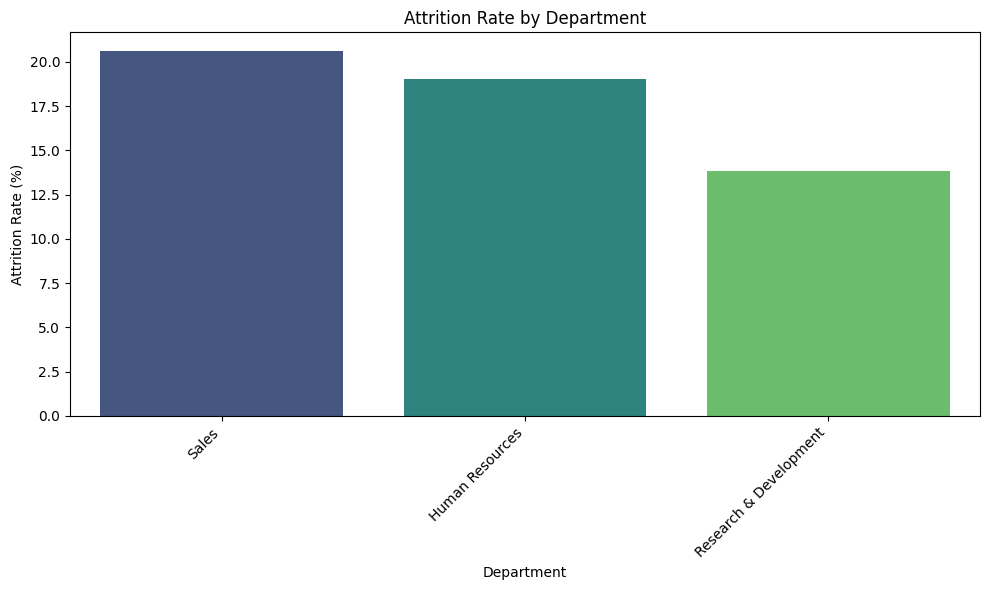

In [34]:
fig_dept, ax_dept = plt.subplots(figsize=(10, 6))
sns.barplot(x=dept_summary.index, y='Attrition Rate (%)', data=dept_summary, palette='viridis', ax=ax_dept, hue=dept_summary.index, legend=False)
ax_dept.set_title('Attrition Rate by Department')
ax_dept.set_xlabel('Department')
ax_dept.set_ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

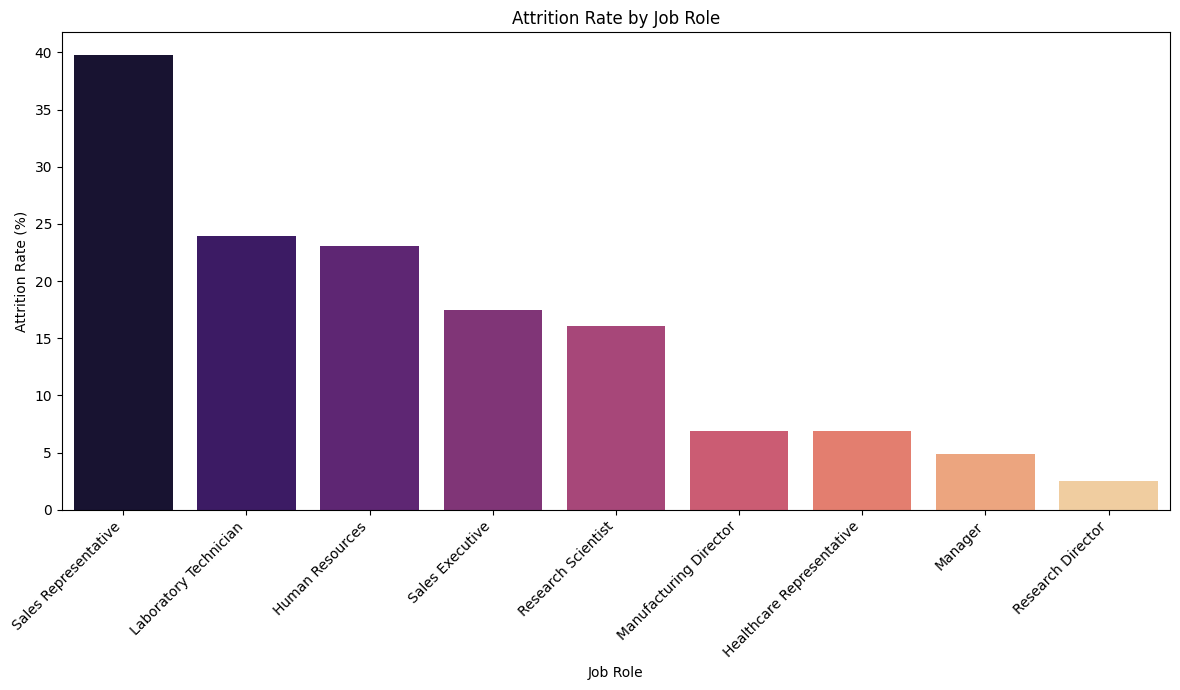

In [36]:
fig_role, ax_role = plt.subplots(figsize=(12, 7))
sns.barplot(x=role_summary.index, y='Attrition Rate (%)', data=role_summary, palette='magma', ax=ax_role, hue=role_summary.index, legend=False)
ax_role.set_title('Attrition Rate by Job Role')
ax_role.set_xlabel('Job Role')
ax_role.set_ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Box plot comparing Monthly Income of employees who left vs stayed

/tmp/ipykernel_1585/4069421488.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda, ax=ax_income, palette='viridis')


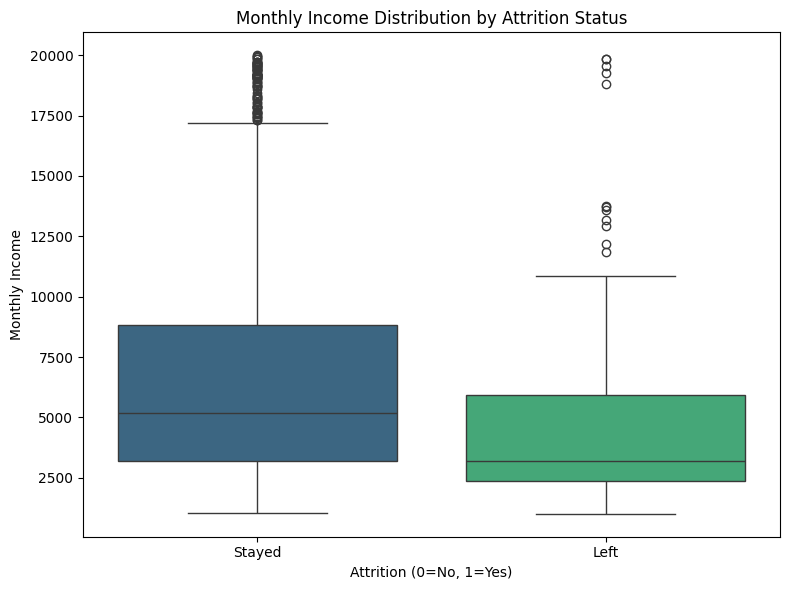

In [38]:
fig_income, ax_income = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda, ax=ax_income, palette='viridis')
ax_income.set_title('Monthly Income Distribution by Attrition Status')
ax_income.set_xlabel('Attrition (0=No, 1=Yes)')
ax_income.set_ylabel('Monthly Income')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix heatmap for best model

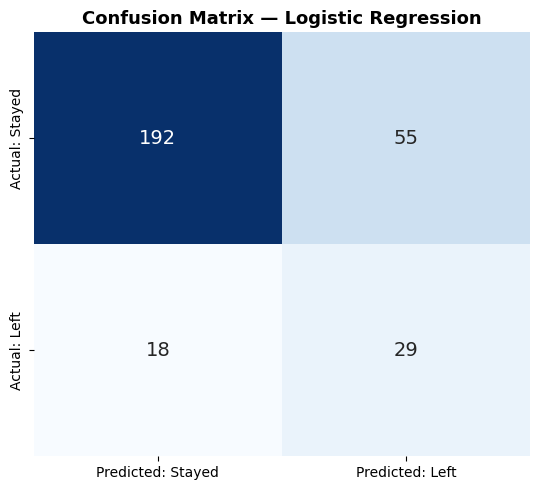

In [42]:
# the best model (Logistic Regression)
best_y_pred, best_y_proba = predictions[best_model_name]
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Stayed', 'Predicted: Left'],
            yticklabels=['Actual: Stayed', 'Actual: Left'], ax=ax, annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
#  Horizontal bar chart of Top 10 Feature Importances from the best model

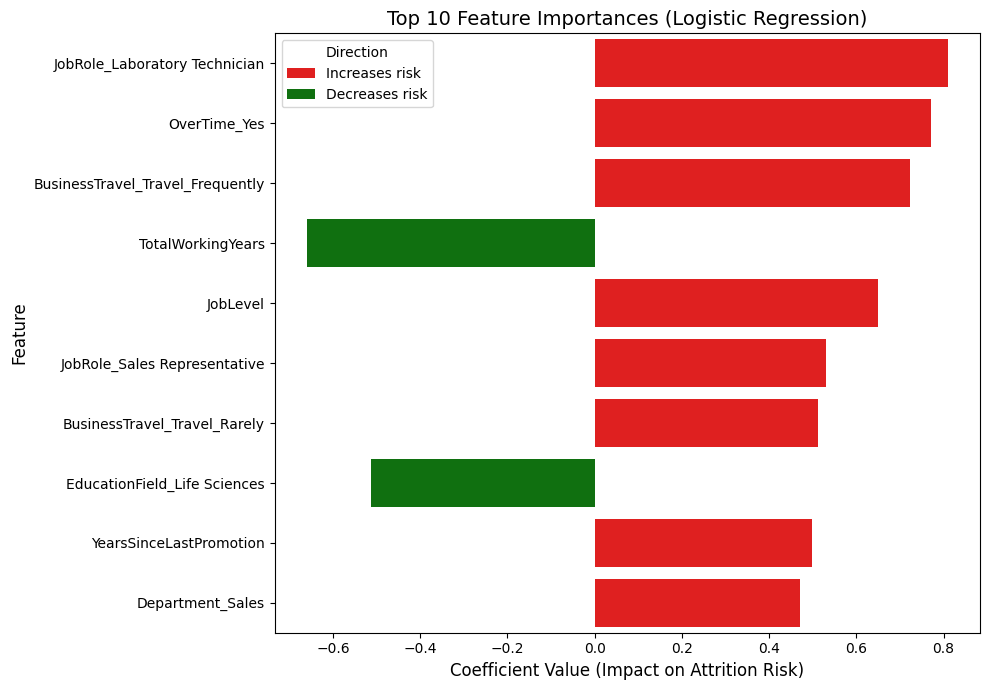

In [43]:
fig_fi, ax_fi = plt.subplots(figsize=(10, 7))
sns.barplot(x='Coefficient', y=top10_df.index, hue='Direction', data=top10_df, dodge=False, palette={'Increases risk': 'red', 'Decreases risk': 'green'}, ax=ax_fi)
ax_fi.set_title('Top 10 Feature Importances (Logistic Regression)', fontsize=14)
ax_fi.set_xlabel('Coefficient Value (Impact on Attrition Risk)', fontsize=12)
ax_fi.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#  ROC Curve comparing all 3 models on one graph

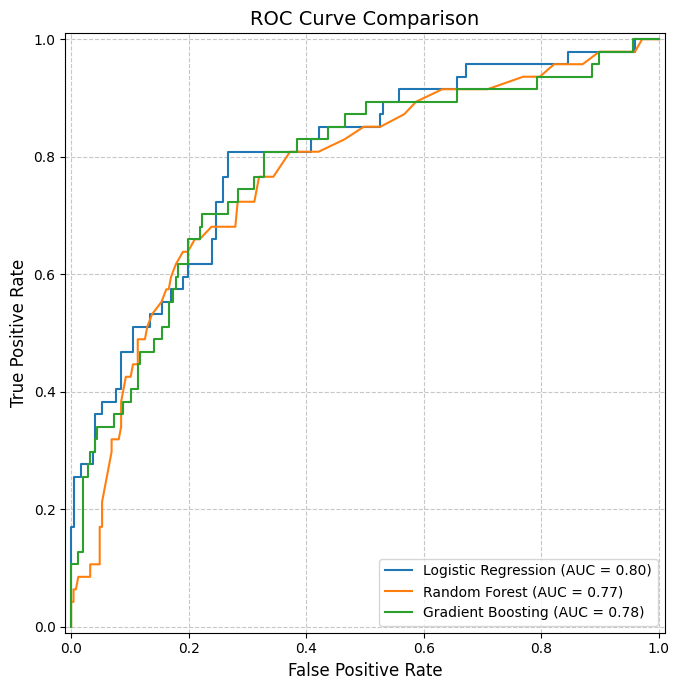

In [48]:
from sklearn.metrics import RocCurveDisplay

fig_roc, ax_roc = plt.subplots(figsize=(10, 7))

for name, (y_pred, y_proba) in predictions.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax_roc)

ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# HR Insights & Business recommendations:

**Which 3 factors most strongly predict that an employee will leave?**

The three biggest red flags that someone might quit:

1. **Working overtime** — People who work overtime leave the company at a rate of 30.5%, compared to just 10.4% for people who don't. That's almost 3x higher. This is the single strongest signal the model found — overtime is basically a stress/burnout warning sign.
2. **Traveling frequently for work** — Employees who travel a lot for their job are also much more likely to leave. Makes sense — constant travel disrupts personal life and adds fatigue, so it wears people down over time.
3. **being new / early in their career** — Employees with fewer total years of work experience are flagged as higher-risk. This lines up with something we saw directly in the data too: 34.9% of employees quit within their very first year at the company. New, less-experienced people simply haven't built loyalty or settled in yet, so they're the most likely to walk.

**Which department or job role should HR prioritize for retention efforts?**

HR should prioritize the Sales department overall (20.6% attrition, the highest of the three departments) and the Sales Representative role specifically, with Laboratory Technicians in R&D as a close second priority.

**Does salary alone explain attrition or are there other stronger factors?**

Salary alone does not explain attrition — leavers earn about 30% less on average, but MonthlyIncome doesn't crack the model's top 10 drivers once overtime, travel, role, and tenure are accounted for; pay is a symptom of role/level, not the root cause.

**Write 2 concrete HR recommendations a company could implement based on your findings**

Action 1: Get overtime under control in the highest-risk teams

-Look closely at how much overtime Sales and Lab Technician employees are actually working — these are the two groups where overtime + role combine to create the biggest quit-risk.

-Set a cap or limit on overtime hours instead of letting it run unchecked.

-Wherever the budget allows, fix the root cause instead of just the symptom: if a team is constantly working overtime, that usually means there aren't enough people to handle the workload. So either hire more people for that team, or spread the existing work more evenly across the team so it doesn't all fall on a few overworked employees.

Action 2: Build a "first 24 months" program to catch new hires before they quit

-We saw that the first year is the most dangerous time — 34.9% of people who quit, quit within their first 12 months. So this is where retention effort should be concentrated.

-Don't wait for someone to hand in their resignation. Be proactive: schedule a check-in conversation with every new hire at 90 days (just past onboarding) and again at 18 months (right before that early-tenure window closes). Ask how they're doing, what's frustrating them, what would make them stay — and actually act on the answers.

-Give people stock options earlier. Right now, employees with zero stock options quit at 24.4%, but employees who have any stock options — even just a little — quit at only 7–9%. That's a huge gap. Giving new hires a small equity stake sooner (instead of making them wait years to qualify) gives them a real financial reason to stick around and feel like they have a stake in the company's success.

**What limitation does this model have that an HR team should be aware of before using it?**

This data is basically a single snapshot in time — just 1,470 employees, and it looks like a clean, almost "textbook" dataset rather than messy real-world HR records. So it's a decent starting point, but it's not the same as having years of your actual company's data.
Also, only about 16 out of every 100 people in this dataset actually left. That's a pretty small slice, and it makes the model's job harder — there just isn't a ton of "this person quit" data to learn from. And one more thing — this shouldn't be a "set it and forget it" tool. People change, policies change, the job market changes. So this model needs to be checked and retrained every so often using fresher data, otherwise it'll quietly become less accurate over time without anyone noticing.